In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


### Plot hyperparameter sampling trials

5.560009511938345 -0.0318063192
16.397206345338915 -0.0318087631
11.984982118895969 -0.0318085172
0.4088213673039241 -0.0317936128
2.1129758570806083 -0.0318004572
0.1731791767809194 -0.0317867357
17.43242747862917 -0.0318092713
5.589560165891216 -0.0318081234
6.767919457388996 -0.031809089
42.23256316668895 -0.0318099899
0.30291938519133527 -0.0317894537
42.777331298627644 -0.0318092619
17.559330352553154 -0.0318094958
25.60019422855708 -0.031809585
1.228322110505373 -0.0317962162
1.1776579805983562 -0.0317971267


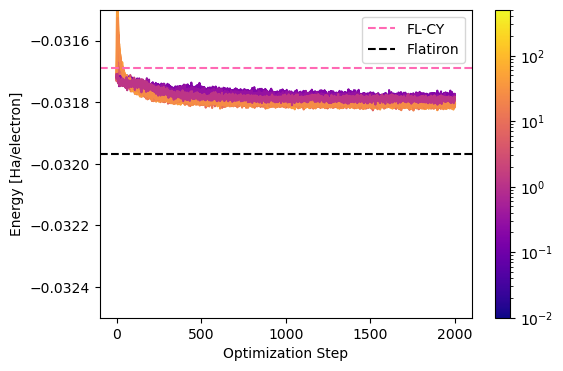

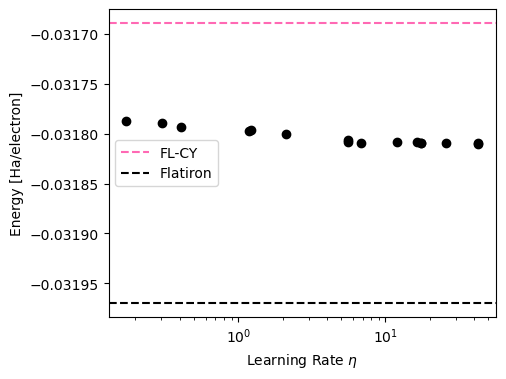

In [2]:
path = "gaussian-reference/MP-init-gaussian/rs{}_trial{}/{}"

r_ws = "30"

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for trial in range(16):

    energy_traj = np.loadtxt(path.format(
        r_ws, str(trial), "energy_traj.txt"
    ))
    eta = np.loadtxt(path.format(
        r_ws, str(trial), "hyperparameters.txt"
    ))

    (mean,_) = trajectory.getStatistics(path.format(
        r_ws, str(trial), "statistics.txt"
    ))
    final_vals.append([eta, mean])

    print(eta, mean)

    if mean is None:
        continue;
    
    color = cmap(norm(eta))
    plt.plot(energy_traj, color=color)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

min_val = np.nanmin([hard_vals[r_ws][0],hard_vals[r_ws][2]])
max_val = np.nanmax([hard_vals[r_ws][0],hard_vals[r_ws][2]])
#plt.ylim([1.1*min_val,0.9*max_val])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # older matplotlib compatibility
cbar = plt.colorbar(sm, ax=plt.gca())

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

final_vals = np.array(final_vals)

plt.figure(figsize=(5,4))
plt.scatter(final_vals[:,0], final_vals[:,1], color='black')
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()